polygons, width=1 , inset+floor 


Loading from: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv

Min complexity: 0.0
Max complexity: 11.112439506781552

Bin width = 1.0
Number of bins = 12
Epsilon floor value = 5.000e-10


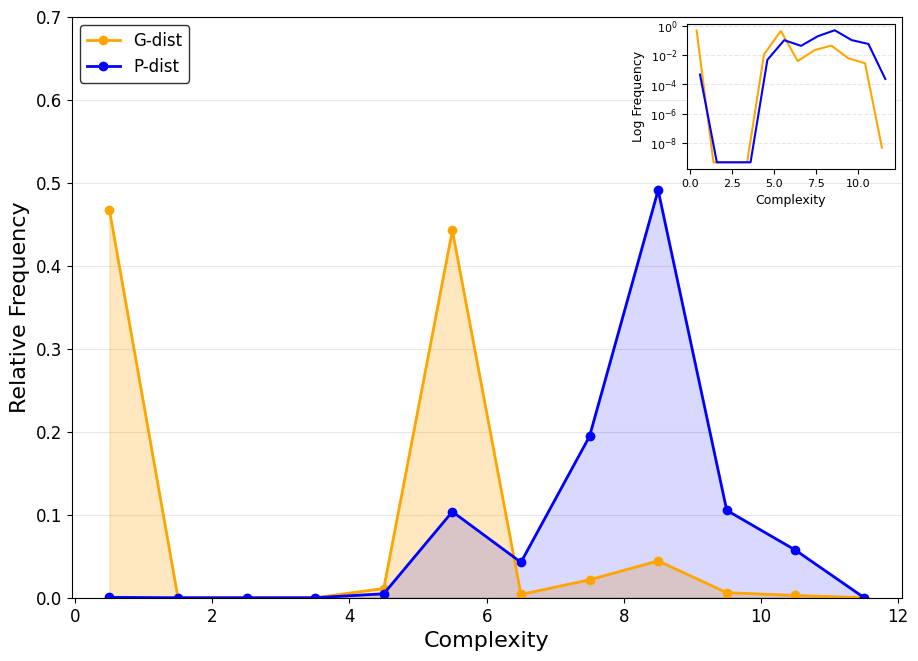

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# File paths
# ===================================
file_path = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
    "circadian/mut_project_updates/figures/RNA/L_18/"
    "plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv"
)

# ===================================
# Load dataset
# ===================================
def load_rna(file_path):
    print(f"\nLoading from: {file_path}")
    df = pd.read_csv(file_path, sep=r"\s+|\t|,", engine="python")
    df.columns = df.columns.str.strip()
    df = df[df["Status"].isin(["Rand", "0muts"])]
    df_rand = df[df["Status"] == "Rand"].copy()
    df_p = df[df["Status"] == "0muts"].copy()
    df_rand["RelFreq"] = df_rand["Freq"] / df_rand["Freq"].sum()
    df_p["RelFreq"] = df_p["Freq"] / df_p["Freq"].sum()
    return df_rand, df_p

df_rand, df_p = load_rna(file_path)

# ===================================
# Shared range
# ===================================
all_vals = np.concatenate([df_rand["Complexity"], df_p["Complexity"]])
min_val = all_vals.min()
max_val = all_vals.max()

print(f"\nMin complexity: {min_val}")
print(f"Max complexity: {max_val}")

# ===================================
# Fixed bin width
# ===================================
bin_width = 1.0
bins = np.arange(min_val, max_val + bin_width, bin_width)
n_bins = len(bins) - 1

print(f"\nBin width = {bin_width}")
print(f"Number of bins = {n_bins}")

# Histogram (PMF already via weights)
rand_counts, bin_edges = np.histogram(
    df_rand["Complexity"],
    bins=bins,
    weights=df_rand["RelFreq"]
)

p_counts, _ = np.histogram(
    df_p["Complexity"],
    bins=bins,
    weights=df_p["RelFreq"]
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Adaptive epsilon floor (log inset)
# ===================================
all_nonzero = np.concatenate([
    rand_counts[rand_counts > 0],
    p_counts[p_counts > 0]
])

eps = np.min(all_nonzero) * 0.1
print(f"Epsilon floor value = {eps:.3e}")

rand_safe = np.clip(rand_counts, eps, None)
p_safe = np.clip(p_counts, eps, None)

# ===================================
# Main Plot
# ===================================
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(bin_centers, rand_counts, marker='o',
        linewidth=2, color="orange", label="G-dist")
ax.fill_between(bin_centers, rand_counts, 0,
                color="orange", alpha=0.25)

ax.plot(bin_centers, p_counts, marker='o',
        linewidth=2, color="blue", label="P-dist")
ax.fill_between(bin_centers, p_counts, 0,
                color="blue", alpha=0.15)

ax.set_xlabel("Complexity", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

ax.legend(frameon=True, edgecolor="black",
          fontsize=12, loc="upper left")

ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# ===================================
# Inset (log-y with floor)
# ===================================
ax_inset = inset_axes(ax, width="25%", height="25%", loc="upper right")

bin_spacing = bin_centers[1] - bin_centers[0]
offset = 0.10 * bin_spacing

ax_inset.plot(bin_centers - offset, rand_safe,
              linewidth=1.5, color="orange")

ax_inset.plot(bin_centers + offset, p_safe,
              linewidth=1.5, color="blue")

ax_inset.set_yscale("log")
ax_inset.set_xlabel("Complexity", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)
ax.set_ylim(0, 0.7)
ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y",
              alpha=0.3, linestyle="--")

plt.subplots_adjust(left=0.12, right=0.95,
                    top=0.95, bottom=0.12)

plt.show()

polygon L=18


Loading from: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv

Data range: 0.000 → 11.112
Bin width = 0.25
Number of bins = 45


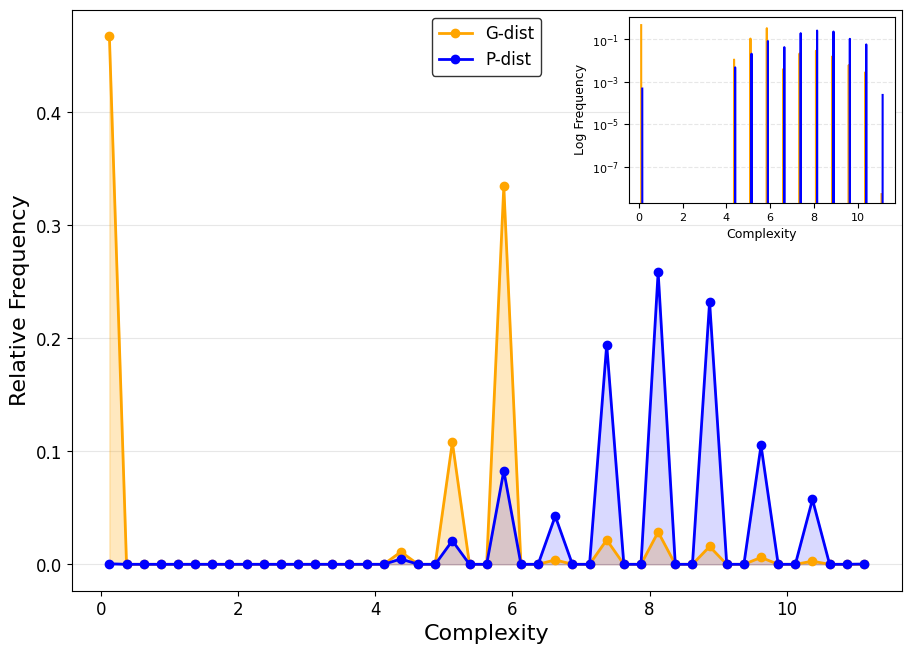

Min complexity: 0.0
Max complexity: 11.112439506781552
Width corresponding to ~30 bins: 0.37041465022605174


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# File paths
# ===================================

file_path = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
    "circadian/mut_project_updates/figures/RNA/L_18/"
    "plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv"
)

# ===================================
# Load dataset
# ===================================

def load_rna(file_path):

    print(f"\nLoading from: {file_path}")

    df = pd.read_csv(file_path, sep=r"\s+|\t|,", engine="python")
    df.columns = df.columns.str.strip()

    df = df[df["Status"].isin(["Rand", "0muts"])]

    df_rand = df[df["Status"] == "Rand"].copy()
    df_p = df[df["Status"] == "0muts"].copy()

    df_rand["RelFreq"] = df_rand["Freq"] / df_rand["Freq"].sum()
    df_p["RelFreq"] = df_p["Freq"] / df_p["Freq"].sum()

    return df_rand, df_p


df_rand, df_p = load_rna(file_path)

# ===================================
# Histogram settings
# ===================================

bin_width = 0.25

all_vals = np.concatenate([df_rand["Complexity"], df_p["Complexity"]])
min_val = all_vals.min()
max_val = all_vals.max()

bins = np.arange(min_val, max_val + bin_width, bin_width)

print(f"\nData range: {min_val:.3f} → {max_val:.3f}")
print(f"Bin width = {bin_width}")
print(f"Number of bins = {len(bins)-1}")

# Weighted histogram (already PMF)
rand_counts, bin_edges = np.histogram(
    df_rand["Complexity"],
    bins=bins,
    weights=df_rand["RelFreq"]
)

p_counts, _ = np.histogram(
    df_p["Complexity"],
    bins=bins,
    weights=df_p["RelFreq"]
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Main Plot (Polygon + Shading)
# ===================================

fig, ax = plt.subplots(figsize=(10, 7))

# Rand first
ax.plot(bin_centers,
        rand_counts,
        marker='o',
        linewidth=2,
        color="orange",
        label="G-dist")

ax.fill_between(bin_centers,
                rand_counts,
                0,
                color="orange",
                alpha=0.25)

# 0muts second
ax.plot(bin_centers,
        p_counts,
        marker='o',
        linewidth=2,
        color="blue",
        label="P-dist")

ax.fill_between(bin_centers,
                p_counts,
                0,
                color="blue",
                alpha=0.15)

ax.set_xlabel("Complexity", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

# Boxed legend, G above P
handles, labels = ax.get_legend_handles_labels()
order = [0, 1]   # G-dist first
ax.legend([handles[i] for i in order],
          [labels[i] for i in order],
          frameon=True,
          edgecolor="black",
          fontsize=12,
          loc="upper center")

ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# ===================================
# Inset (Polygon, log-y)
# ===================================

ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

# Optional offset if overlapping
bin_spacing = bin_centers[1] - bin_centers[0]
offset = 0.10 * bin_spacing

ax_inset.plot(bin_centers - offset,
              rand_counts,
              linewidth=1.5,
              color="orange")

ax_inset.plot(bin_centers + offset,
              p_counts,
              linewidth=1.5,
              color="blue")

ax_inset.set_yscale("log")
ax_inset.set_xlabel("Complexity", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)

ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

plt.subplots_adjust(left=0.12, right=0.95, top=0.95, bottom=0.12)
plt.show()
print("Min complexity:", min_val)
print("Max complexity:", max_val)
approx_width = (max_val - min_val) / 30
print("Width corresponding to ~30 bins:", approx_width)

test many bins


Loading from: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv

Min complexity: 0.0
Max complexity: 11.112439506781552

Bin width = 0.250000  →  Number of bins = 45


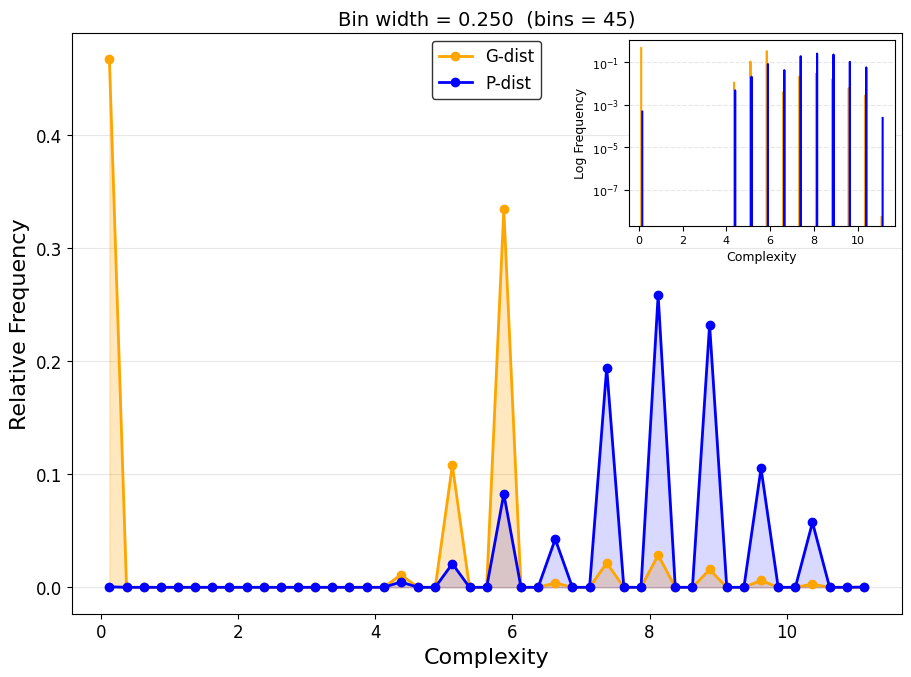


Bin width = 0.370415  →  Number of bins = 30


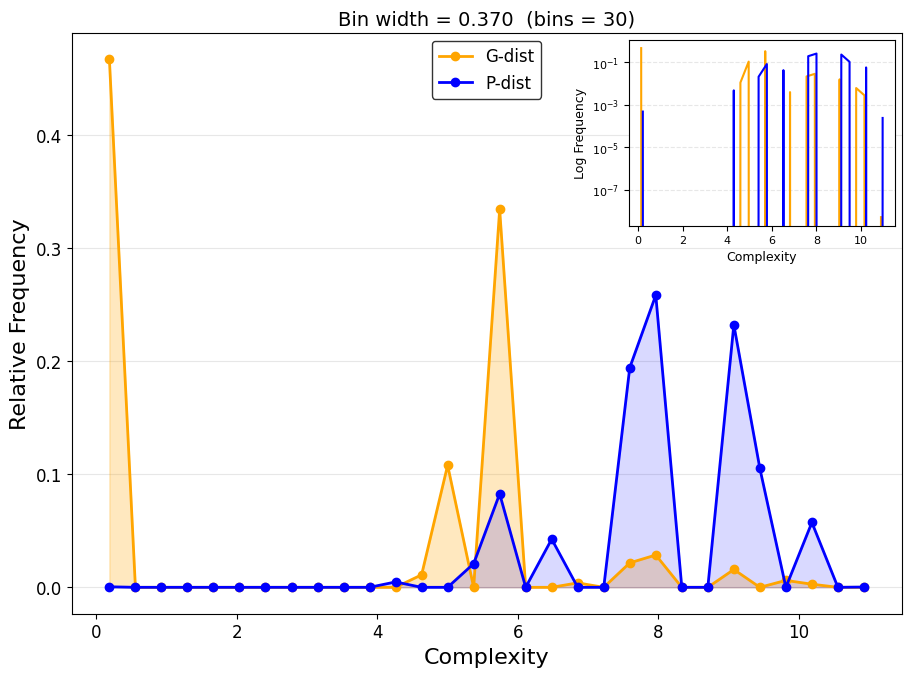


Bin width = 0.500000  →  Number of bins = 23


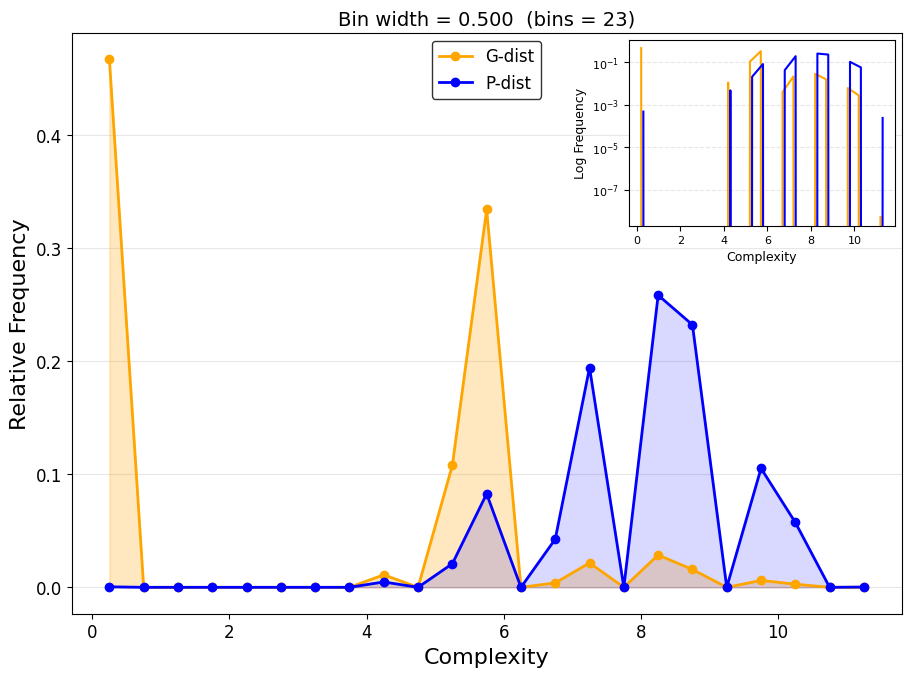


Bin width = 0.750000  →  Number of bins = 15


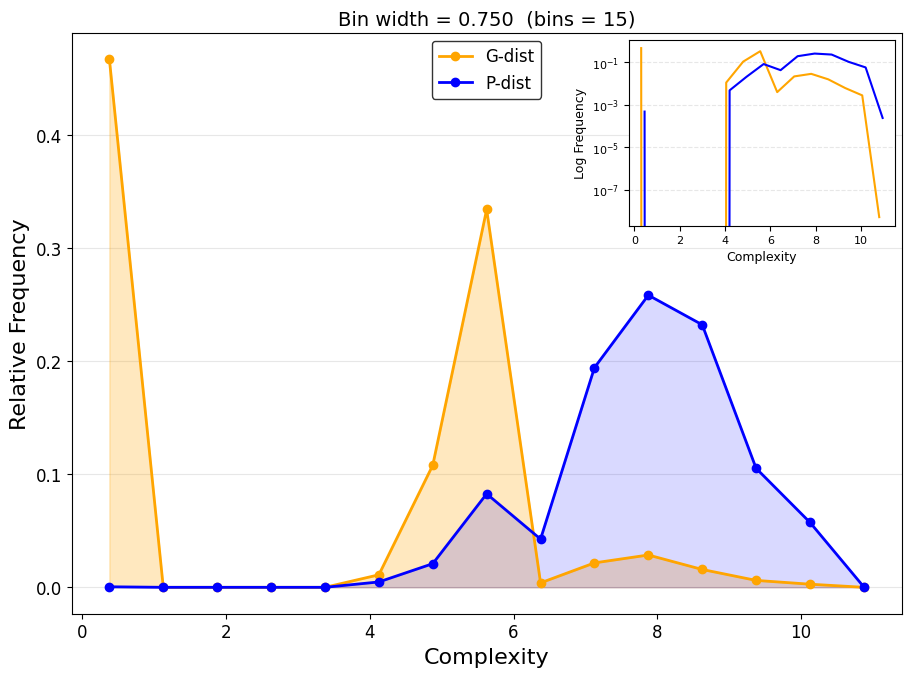


Bin width = 1.000000  →  Number of bins = 12


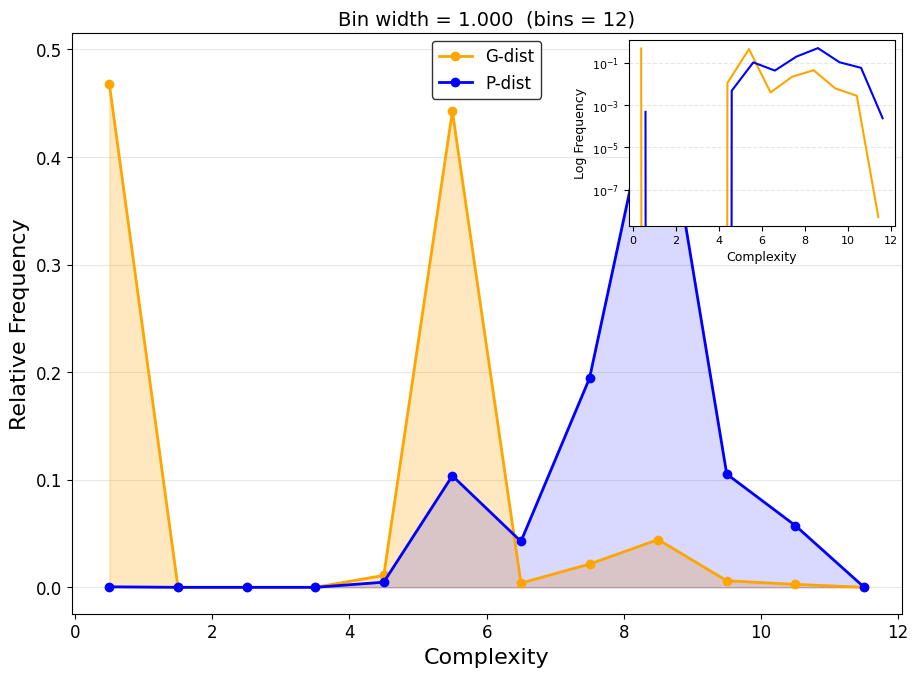


Bin width = 1.500000  →  Number of bins = 8


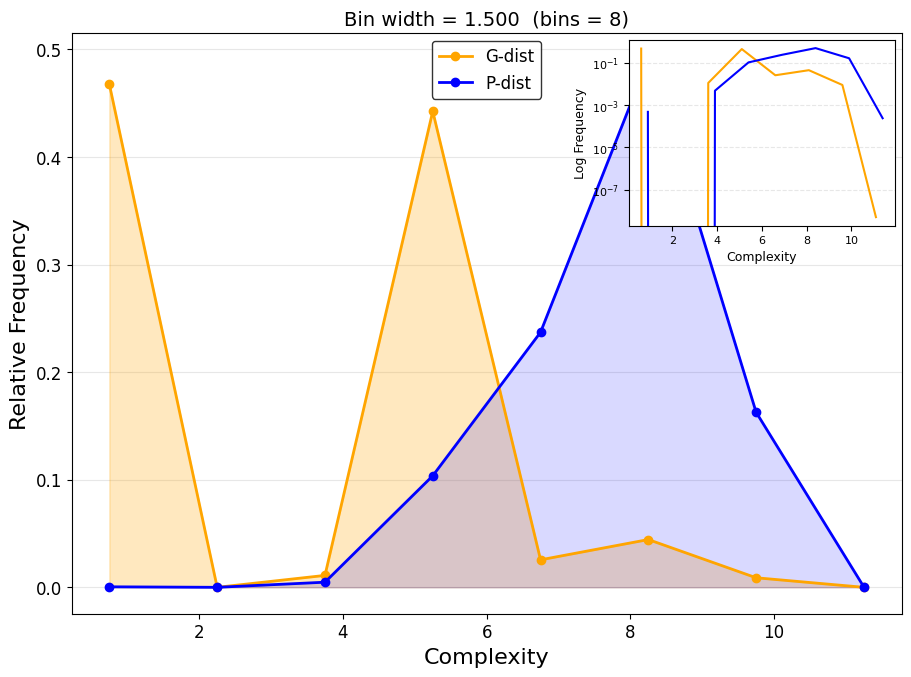

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# File paths
# ===================================
file_path = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/"
    "circadian/mut_project_updates/figures/RNA/L_18/"
    "plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv"
)

# ===================================
# Load dataset
# ===================================
def load_rna(file_path):
    print(f"\nLoading from: {file_path}")
    df = pd.read_csv(file_path, sep=r"\s+|\t|,", engine="python")
    df.columns = df.columns.str.strip()
    df = df[df["Status"].isin(["Rand", "0muts"])]
    df_rand = df[df["Status"] == "Rand"].copy()
    df_p = df[df["Status"] == "0muts"].copy()
    df_rand["RelFreq"] = df_rand["Freq"] / df_rand["Freq"].sum()
    df_p["RelFreq"] = df_p["Freq"] / df_p["Freq"].sum()
    return df_rand, df_p

df_rand, df_p = load_rna(file_path)

# ===================================
# Shared range
# ===================================
all_vals = np.concatenate([df_rand["Complexity"], df_p["Complexity"]])
min_val = all_vals.min()
max_val = all_vals.max()
print(f"\nMin complexity: {min_val}")
print(f"Max complexity: {max_val}")

# ===================================
# Bin widths to try (recommended)
# ===================================
bin_widths = [
    0.25,
    0.37041465022605174,  # ≈ original 30-bin width
    0.5,
    0.75,
    1.0,
    1.5
]

# ===================================
# Loop and plot
# ===================================
for bin_width in bin_widths:
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    n_bins = len(bins) - 1
    print(f"\nBin width = {bin_width:.6f}  →  Number of bins = {n_bins}")

    rand_counts, bin_edges = np.histogram(df_rand["Complexity"], bins=bins, weights=df_rand["RelFreq"])
    p_counts, _ = np.histogram(df_p["Complexity"], bins=bins, weights=df_p["RelFreq"])
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    fig, ax = plt.subplots(figsize=(10, 7))

    # Main polygons
    ax.plot(bin_centers, rand_counts, marker='o', linewidth=2, color="orange", label="G-dist")
    ax.fill_between(bin_centers, rand_counts, 0, color="orange", alpha=0.25)

    ax.plot(bin_centers, p_counts, marker='o', linewidth=2, color="blue", label="P-dist")
    ax.fill_between(bin_centers, p_counts, 0, color="blue", alpha=0.15)

    ax.set_xlabel("Complexity", fontsize=16)
    ax.set_ylabel("Relative Frequency", fontsize=16)
    ax.set_title(f"Bin width = {bin_width:.3f}  (bins = {n_bins})", fontsize=14)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, frameon=True, edgecolor="black", fontsize=12, loc="upper center")

    ax.tick_params(labelsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

    # Inset (log-y)
    ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")
    bin_spacing = bin_centers[1] - bin_centers[0]
    offset = 0.10 * bin_spacing

    ax_inset.plot(bin_centers - offset, rand_counts, linewidth=1.5, color="orange")
    ax_inset.plot(bin_centers + offset, p_counts, linewidth=1.5, color="blue")
    ax_inset.set_yscale("log")
    ax_inset.set_xlabel("Complexity", fontsize=9)
    ax_inset.set_ylabel("Log Frequency", fontsize=9)
    ax_inset.tick_params(labelsize=8)
    ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

    plt.subplots_adjust(left=0.12, right=0.95, top=0.95, bottom=0.12)
    plt.show()